
Total sequences: 388
domain_label
A_normal    169
CAL         135
Ak           84
Name: count, dtype: int64
Using device: cuda
Processed 4/388
Processed 8/388
Processed 12/388
Processed 16/388
Processed 20/388
Processed 24/388
Processed 28/388
Processed 32/388
Processed 36/388
Processed 40/388
Processed 44/388
Processed 48/388
Processed 52/388
Processed 56/388
Processed 60/388
Processed 64/388
Processed 68/388
Processed 72/388
Processed 76/388
Processed 80/388
Processed 84/388
Processed 88/388
Processed 92/388
Processed 96/388
Processed 100/388
Processed 104/388
Processed 108/388
Processed 112/388
Processed 116/388
Processed 120/388
Processed 124/388
Processed 128/388
Processed 132/388
Processed 136/388
Processed 140/388
Processed 144/388
Processed 148/388
Processed 152/388
Processed 156/388
Processed 160/388
Processed 164/388
Processed 168/388
Processed 172/388
Processed 176/388
Processed 180/388
Processed 184/388
Processed 188/388
Processed 192/388
Processed 196/388
Processed 200/38

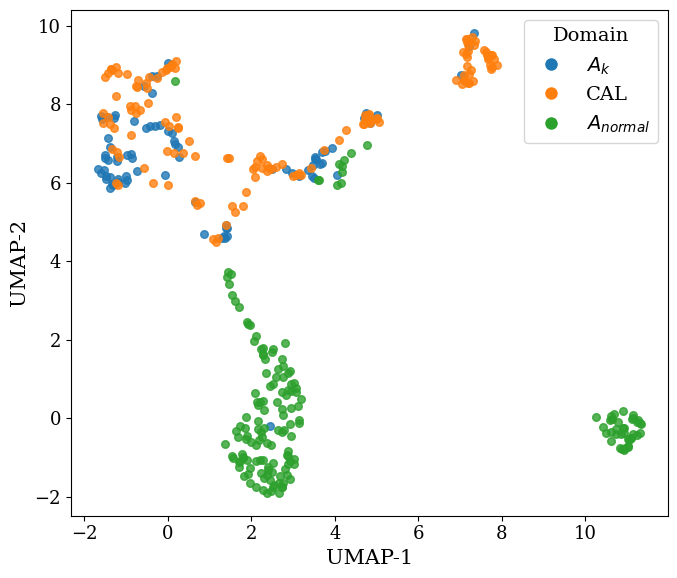

Done. Plot saved: testset_A_Ak_CAL_UMAP.png


In [30]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
from matplotlib.lines import Line2D
import esm


# ==============================
# Step 0: Settings
# ==============================
fasta_file = "clu_85_rep_seq.fasta"

output_embedding_file = "testset_A_Ak_CAL_embeddings.npy"
output_table_file = "testset_A_Ak_CAL_table.xlsx"
output_umap_xlsx = "testset_A_Ak_CAL_UMAP_coordinates.xlsx"
output_umap_csv = "testset_A_Ak_CAL_UMAP_coordinates.csv"
output_plot = "testset_A_Ak_CAL_UMAP.png"

batch_size = 4


# ==============================
# Step 1: Read FASTA + assign labels
# ==============================
records = []
header = None
seq_lines = []


def infer_label(header_text):
    h = header_text.strip()
    tokens = re.split(r"[|\s,;/]+", h)
    tokens_upper = [t.upper() for t in tokens if t.strip()]

    # priority: Ak > CAL > A
    for t in tokens_upper:
        if t == "AK":
            return "Ak"
    for t in tokens_upper:
        if t == "CAL":
            return "CAL"
    for t in tokens_upper:
        if t == "A":
            return "A_normal"

    # fallback
    hu = h.upper()
    if "AK" in hu:
        return "Ak"
    if "CAL" in hu:
        return "CAL"
    if re.search(r"(^|[^A-Z])A([^A-Z]|$)", hu):
        return "A_normal"

    return None


def save_record(header_text, seq_lines):
    if header_text is None:
        return None

    seq = "".join(seq_lines).strip().replace(" ", "").upper()
    if not seq:
        return None

    label = infer_label(header_text)
    if label is None:
        print("Skipping:", header_text)
        return None

    return {
        "id": header_text,
        "sequence": seq,
        "domain_label": label
    }


with open(fasta_file, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        if line.startswith(">"):
            rec = save_record(header, seq_lines)
            if rec:
                records.append(rec)
            header = line[1:]
            seq_lines = []
        else:
            seq_lines.append(line)

    rec = save_record(header, seq_lines)
    if rec:
        records.append(rec)

df = pd.DataFrame(records)

print("\nTotal sequences:", len(df))
print(df["domain_label"].value_counts())


# ==============================
# Step 2: Load ESM-2
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model = model.to(device)
model.eval()


# ==============================
# Step 3: Generate embeddings
# ==============================
seqs = df["sequence"].tolist()
ids = df["id"].tolist()

embeddings = []

for start in range(0, len(seqs), batch_size):
    batch = list(zip(ids[start:start+batch_size], seqs[start:start+batch_size]))

    _, _, tokens = batch_converter(batch)
    tokens = tokens.to(device)

    with torch.no_grad():
        results = model(tokens, repr_layers=[model.num_layers])

    reps = results["representations"][model.num_layers]

    for i, (_, seq) in enumerate(batch):
        emb = reps[i, 1:len(seq)+1].mean(0).cpu().numpy()
        embeddings.append(emb)

    print(f"Processed {min(start+batch_size, len(seqs))}/{len(seqs)}")

X = np.array(embeddings)

print("Embedding shape:", X.shape)

np.save(output_embedding_file, X)
df.to_excel(output_table_file, index=False)


# ==============================
# Step 4: UMAP
# ==============================
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

emb_2d = reducer.fit_transform(X)


# ==============================
# Step 5: Save coordinates
# ==============================
df["UMAP1"] = emb_2d[:, 0]
df["UMAP2"] = emb_2d[:, 1]

df.to_excel(output_umap_xlsx, index=False)
df.to_csv(output_umap_csv, index=False)


# ==============================
# Step 6: Plot
# ==============================
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "font.size": 14
})

color_map = {
    "Ak": plt.cm.tab10.colors[0],
    "CAL": plt.cm.tab10.colors[1],
    "A_normal": plt.cm.tab10.colors[2]
}

display_map = {
    "Ak": r"$A_k$",
    "CAL": "CAL",
    "A_normal": r"$A_{normal}$"
}

plt.figure(figsize=(7,6))

for label in ["Ak", "CAL", "A_normal"]:
    mask = df["domain_label"] == label
    if mask.sum() == 0:
        continue

    plt.scatter(
        emb_2d[mask,0],
        emb_2d[mask,1],
        c=[color_map[label]],
        s=30,
        alpha=0.8
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

legend_elements = [
    Line2D([0],[0], marker='o', color='w',
           label=display_map[l],
           markerfacecolor=color_map[l],
           markersize=10)
    for l in ["Ak","CAL","A_normal"]
    if l in df["domain_label"].values
]

plt.legend(handles=legend_elements, title="Domain", loc="best")

plt.tight_layout()
plt.savefig(output_plot, dpi=1000)
plt.show()

print("Done. Plot saved:", output_plot)

In [3]:
import warnings
import os
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")


# =========================================================
# 0. SETTINGS
# =========================================================
EMBEDDING_FILE = "testset_A_Ak_CAL_embeddings.npy"
METADATA_FILE = "testset_A_Ak_CAL_table.xlsx"

OUTPUT_OVERALL_XLSX = "testset_multiclass_classifier_overall_results.xlsx"
OUTPUT_OVERALL_TSV = "testset_multiclass_classifier_overall_results.tsv"
OUTPUT_PER_CLASS_XLSX = "testset_multiclass_classifier_per_class_results.xlsx"
OUTPUT_PREDICTIONS_XLSX = "testset_multiclass_classifier_fold_predictions.xlsx"
OUTPUT_LABEL_MAP_XLSX = "testset_multiclass_classifier_label_mapping.xlsx"

MODEL_OUTPUT_DIR = "saved_models"

RANDOM_STATE = 42
N_SPLITS = 5


# =========================================================
# 1. LOAD EMBEDDINGS
# =========================================================
X = np.load(EMBEDDING_FILE)

print("=" * 60)
print("Loaded embedding file:", EMBEDDING_FILE)
print("Embedding shape:", X.shape)
print("=" * 60)


# =========================================================
# 2. LOAD METADATA
# =========================================================
if METADATA_FILE.endswith(".xlsx"):
    df = pd.read_excel(METADATA_FILE)
elif METADATA_FILE.endswith(".csv"):
    df = pd.read_csv(METADATA_FILE)
elif METADATA_FILE.endswith(".tsv"):
    df = pd.read_csv(METADATA_FILE, sep="\t")
else:
    raise ValueError("Unsupported metadata file format")

print("Loaded metadata file:", METADATA_FILE)
print("Metadata rows:", len(df))
print("Columns:", df.columns.tolist())

if len(df) != X.shape[0]:
    raise ValueError(
        f"Metadata rows ({len(df)}) do not match embedding rows ({X.shape[0]})."
    )


# =========================================================
# 3. CLEAN LABELS
# =========================================================
if "domain_label" in df.columns:
    df["domain_label"] = df["domain_label"].astype(str).str.strip()
elif "domain_type" in df.columns:
    df["domain_label"] = df["domain_type"].astype(str).str.strip()
else:
    raise ValueError("Could not find 'domain_label' or 'domain_type' column.")

def normalize_label(x):
    s = str(x).strip().upper().replace("-", "_").replace(" ", "_")

    if s in {"A", "A_NORMAL", "ANORMAL", "A_NORMAL_DOMAIN"}:
        return "A_normal"

    if s in {"AK", "AK_DOMAIN", "AMP", "AMP_BINDING", "AMPBINDING"}:
        return "Ak"

    if s in {"CAL", "CAL_DOMAIN", "CALDOMAIN"}:
        return "CAL"

    return x

df["domain_label"] = df["domain_label"].apply(normalize_label)

target_classes = ["A_normal", "Ak", "CAL"]
keep_idx = df[df["domain_label"].isin(target_classes)].index

df = df.loc[keep_idx].copy().reset_index(drop=True)
X = X[keep_idx]

print("\nFinal label counts:")
print(df["domain_label"].value_counts())

if len(df) != X.shape[0]:
    raise ValueError("Filtered metadata rows do not match embedding rows.")

if len(df["domain_label"].unique()) != 3:
    raise ValueError(
        f"Expected 3 classes, but found: {sorted(df['domain_label'].unique())}"
    )


# =========================================================
# 4. ENCODE LABELS
# =========================================================
le = LabelEncoder()
y = le.fit_transform(df["domain_label"])

print("\nEncoded classes:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

n_classes = len(le.classes_)

if "id" not in df.columns:
    df["id"] = [f"seq_{i}" for i in range(len(df))]


# =========================================================
# 5. DEFINE MODELS
# =========================================================
def make_model(model_name, weighted=False):
    if model_name == "LogisticRegression":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=5000,
                class_weight="balanced" if weighted else None,
                random_state=RANDOM_STATE
            ))
        ])

    elif model_name == "SVM":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                probability=True,
                class_weight="balanced" if weighted else None,
                random_state=RANDOM_STATE
            ))
        ])

    elif model_name == "RandomForest":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("clf", RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced" if weighted else None,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    elif model_name == "XGBoost":
        return Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("clf", XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=n_classes,
                eval_metric="mlogloss",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

    else:
        raise ValueError(f"Unknown model: {model_name}")


model_names = ["LogisticRegression", "SVM", "RandomForest", "XGBoost"]


# =========================================================
# 6. CROSS-VALIDATION
# =========================================================
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

overall_results = []
per_class_results = []
all_fold_predictions = []

for weighting in [False, True]:
    weight_mode = "weighted" if weighting else "unweighted"

    print("\n" + "=" * 60)
    print("Running:", weight_mode)
    print("=" * 60)

    for model_name in model_names:
        print(f"\nModel: {model_name}")

        accs, f1s, precs, recs = [], [], [], []
        auc_macro_ovr, auc_weighted_ovr = [], []

        all_y_true = []
        all_y_pred = []

        for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            test_ids = df.loc[test_idx, "id"].tolist()

            model = make_model(model_name=model_name, weighted=weighting)

            if model_name == "XGBoost" and weighting:
                sample_weights = compute_sample_weight(
                    class_weight="balanced",
                    y=y_train
                )
                model.fit(X_train, y_train, clf__sample_weight=sample_weights)
            else:
                model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_score = model.predict_proba(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
            prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
            rec = recall_score(y_test, y_pred, average="macro", zero_division=0)

            auc_macro = roc_auc_score(
                y_test,
                y_score,
                multi_class="ovr",
                average="macro"
            )

            auc_weighted = roc_auc_score(
                y_test,
                y_score,
                multi_class="ovr",
                average="weighted"
            )

            accs.append(acc)
            f1s.append(f1)
            precs.append(prec)
            recs.append(rec)
            auc_macro_ovr.append(auc_macro)
            auc_weighted_ovr.append(auc_weighted)

            all_y_true.extend(y_test.tolist())
            all_y_pred.extend(y_pred.tolist())

            fold_pred_df = pd.DataFrame({
                "Weight_mode": weight_mode,
                "Model": model_name,
                "fold": fold,
                "id": test_ids,
                "true_label": le.inverse_transform(y_test),
                "pred_label": le.inverse_transform(y_pred)
            })

            all_fold_predictions.append(fold_pred_df)

            print(
                f"  Fold {fold}: "
                f"ACC={acc:.4f}, F1={f1:.4f}, PREC={prec:.4f}, "
                f"REC={rec:.4f}, AUC_macro={auc_macro:.4f}, "
                f"AUC_weighted={auc_weighted:.4f}"
            )

        overall_results.append({
            "Weight_mode": weight_mode,
            "Model": model_name,
            "Accuracy_mean": np.mean(accs),
            "Accuracy_std": np.std(accs),
            "F1_macro_mean": np.mean(f1s),
            "F1_macro_std": np.std(f1s),
            "Precision_macro_mean": np.mean(precs),
            "Precision_macro_std": np.std(precs),
            "Recall_macro_mean": np.mean(recs),
            "Recall_macro_std": np.std(recs),
            "ROC_AUC_OVR_macro_mean": np.mean(auc_macro_ovr),
            "ROC_AUC_OVR_macro_std": np.std(auc_macro_ovr),
            "ROC_AUC_OVR_weighted_mean": np.mean(auc_weighted_ovr),
            "ROC_AUC_OVR_weighted_std": np.std(auc_weighted_ovr),
        })

        report = classification_report(
            all_y_true,
            all_y_pred,
            labels=list(range(n_classes)),
            target_names=le.classes_,
            output_dict=True,
            zero_division=0
        )

        for cls_name in le.classes_:
            per_class_results.append({
                "Weight_mode": weight_mode,
                "Model": model_name,
                "Class": cls_name,
                "Precision": report[cls_name]["precision"],
                "Recall": report[cls_name]["recall"],
                "F1_score": report[cls_name]["f1-score"],
                "Support": report[cls_name]["support"]
            })


# =========================================================
# 7. SAVE CV RESULTS
# =========================================================
overall_df = pd.DataFrame(overall_results)

overall_df = overall_df.sort_values(
    by=["F1_macro_mean", "ROC_AUC_OVR_macro_mean", "Accuracy_mean"],
    ascending=False
).reset_index(drop=True)

per_class_df = pd.DataFrame(per_class_results)
pred_df = pd.concat(all_fold_predictions, ignore_index=True)

overall_df.to_excel(OUTPUT_OVERALL_XLSX, index=False)
overall_df.to_csv(OUTPUT_OVERALL_TSV, sep="\t", index=False)
per_class_df.to_excel(OUTPUT_PER_CLASS_XLSX, index=False)
pred_df.to_excel(OUTPUT_PREDICTIONS_XLSX, index=False)

label_map_df = pd.DataFrame({
    "encoded_label": list(range(len(le.classes_))),
    "domain_class": le.classes_
})

label_map_df.to_excel(OUTPUT_LABEL_MAP_XLSX, index=False)

print("\nSaved result files:")
print(" -", OUTPUT_OVERALL_XLSX)
print(" -", OUTPUT_OVERALL_TSV)
print(" -", OUTPUT_PER_CLASS_XLSX)
print(" -", OUTPUT_PREDICTIONS_XLSX)
print(" -", OUTPUT_LABEL_MAP_XLSX)


# =========================================================
# 8. TRAIN FINAL MODELS ON FULL DATASET AND SAVE PKL
# =========================================================
os.makedirs(MODEL_OUTPUT_DIR, exist_ok=True)

print("\n" + "=" * 60)
print("Training final weighted models on FULL dataset and saving PKL files")
print("=" * 60)

for model_name in model_names:
    print(f"\nTraining final model: {model_name}")

    final_model = make_model(model_name=model_name, weighted=True)

    if model_name == "XGBoost":
        sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y
        )
        final_model.fit(X, y, clf__sample_weight=sample_weights)
    else:
        final_model.fit(X, y)

    model_path = os.path.join(
        MODEL_OUTPUT_DIR,
        f"{model_name}_weighted_final_model.pkl"
    )

    with open(model_path, "wb") as f:
        pickle.dump(final_model, f)

    print("Saved:", model_path)


# =========================================================
# 9. SAVE LABEL ENCODER
# =========================================================
label_encoder_path = os.path.join(MODEL_OUTPUT_DIR, "label_encoder.pkl")

with open(label_encoder_path, "wb") as f:
    pickle.dump(le, f)

print("\nSaved:", label_encoder_path)

print("\nDone.")

Loaded embedding file: testset_A_Ak_CAL_embeddings.npy
Embedding shape: (388, 1280)
Loaded metadata file: testset_A_Ak_CAL_table.xlsx
Metadata rows: 388
Columns: ['id', 'sequence', 'domain_label']

Final label counts:
domain_label
A_normal    169
CAL         135
Ak           84
Name: count, dtype: int64

Encoded classes:
0 -> A_normal
1 -> Ak
2 -> CAL

Running: unweighted

Model: LogisticRegression
  Fold 1: ACC=0.8333, F1=0.7767, PREC=0.7926, REC=0.7741, AUC_macro=0.9481, AUC_weighted=0.9598
  Fold 2: ACC=0.8462, F1=0.7977, PREC=0.8114, REC=0.7938, AUC_macro=0.9457, AUC_weighted=0.9551
  Fold 3: ACC=0.9231, F1=0.9001, PREC=0.9223, REC=0.8922, AUC_macro=0.9695, AUC_weighted=0.9759
  Fold 4: ACC=0.9091, F1=0.8838, PREC=0.8968, REC=0.8773, AUC_macro=0.9744, AUC_weighted=0.9789
  Fold 5: ACC=0.8442, F1=0.8180, PREC=0.8202, REC=0.8315, AUC_macro=0.9503, AUC_weighted=0.9604

Model: SVM
  Fold 1: ACC=0.8590, F1=0.8114, PREC=0.8315, REC=0.8061, AUC_macro=0.9389, AUC_weighted=0.9524
  Fold 2: 

In [32]:
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from Bio import pairwise2

warnings.filterwarnings("ignore")


# =========================================================
# 0. SETTINGS
# =========================================================
METADATA_FILE = "testset_A_Ak_CAL_table.xlsx"

OUTPUT_RESULTS_XLSX = "testset_sequence_identity_baseline_5fold_results.xlsx"
OUTPUT_RESULTS_TSV = "testset_sequence_identity_baseline_5fold_results.tsv"
OUTPUT_PRED_XLSX = "testset_sequence_identity_baseline_fold_predictions.xlsx"
OUTPUT_PER_CLASS_XLSX = "testset_sequence_identity_baseline_per_class_results.xlsx"
OUTPUT_LABEL_MAP_XLSX = "testset_sequence_identity_baseline_label_mapping.xlsx"

RANDOM_STATE = 42
N_SPLITS = 5

TARGET_CLASSES = ["A_normal", "Ak", "CAL"]


# =========================================================
# 1. LOAD DATA
# =========================================================
if METADATA_FILE.endswith(".xlsx"):
    df = pd.read_excel(METADATA_FILE)
elif METADATA_FILE.endswith(".csv"):
    df = pd.read_csv(METADATA_FILE)
elif METADATA_FILE.endswith(".tsv"):
    df = pd.read_csv(METADATA_FILE, sep="\t")
else:
    raise ValueError("Unsupported metadata file format")

print("=" * 60)
print("Loaded metadata file:", METADATA_FILE)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("=" * 60)


# =========================================================
# 2. CHECK REQUIRED COLUMNS
# =========================================================
required_cols = ["sequence"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

if "domain_label" in df.columns:
    label_col = "domain_label"
elif "domain_type" in df.columns:
    label_col = "domain_type"
else:
    raise ValueError("Could not find 'domain_label' or 'domain_type' column.")

if "id" not in df.columns:
    df["id"] = [f"seq_{i}" for i in range(len(df))]


# =========================================================
# 3. CLEAN LABELS AND SEQUENCES
# =========================================================
def normalize_label(x):
    s = str(x).strip().upper().replace("-", "_").replace(" ", "_")

    if s in {"A", "A_NORMAL", "ANORMAL", "A_NORMAL_DOMAIN"}:
        return "A_normal"

    if s in {"AK", "AK_DOMAIN", "AMP", "AMP_BINDING", "AMPBINDING"}:
        return "Ak"

    if s in {"CAL", "CAL_DOMAIN", "CALDOMAIN"}:
        return "CAL"

    return x


df["domain_label"] = df[label_col].apply(normalize_label)

df["sequence"] = (
    df["sequence"]
    .astype(str)
    .str.upper()
    .str.replace(r"[^A-Z]", "", regex=True)
)

df = df[df["domain_label"].isin(TARGET_CLASSES)].copy()
df = df[df["sequence"] != ""].copy().reset_index(drop=True)

print("\nFinal label counts:")
print(df["domain_label"].value_counts())

if df["domain_label"].nunique() != 3:
    raise ValueError(f"Expected 3 classes, found: {df['domain_label'].unique()}")


# =========================================================
# 4. OPTIONAL: REMOVE EXACT DUPLICATES
# =========================================================
before = len(df)
df = df.drop_duplicates(subset=["sequence", "domain_label"]).reset_index(drop=True)
after = len(df)
print(f"\nRemoved exact duplicate sequence+label rows: {before - after}")
print("Rows after deduplication:", len(df))


# =========================================================
# 5. ENCODE LABELS
# =========================================================
label_order = ["A_normal", "Ak", "CAL"]
label_to_int = {label: i for i, label in enumerate(label_order)}
int_to_label = {i: label for label, i in label_to_int.items()}

y = df["domain_label"].map(label_to_int).values
seqs = df["sequence"].tolist()
ids = df["id"].tolist()

print("\nEncoded classes:")
for label in label_order:
    print(label_to_int[label], "->", label)


# =========================================================
# 6. SEQUENCE IDENTITY FUNCTION
# =========================================================
def calc_sequence_identity(seq1, seq2):
    """
    Global sequence identity baseline.
    Identity = matches / alignment length
    """
    aln = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)[0]
    aligned_seq1 = aln.seqA
    aligned_seq2 = aln.seqB

    matches = sum(a == b for a, b in zip(aligned_seq1, aligned_seq2))
    aln_len = len(aligned_seq1)

    if aln_len == 0:
        return 0.0

    return matches / aln_len


# =========================================================
# 7. CROSS-VALIDATION
# =========================================================
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

accs, f1s, precs, recs = [], [], [], []
all_fold_predictions = []
per_class_results = []

for fold, (train_idx, test_idx) in enumerate(cv.split(seqs, y), start=1):
    print("\n" + "=" * 60)
    print(f"Fold {fold}")
    print("=" * 60)

    train_seqs = [seqs[i] for i in train_idx]
    train_labels = [y[i] for i in train_idx]
    train_ids = [ids[i] for i in train_idx]

    test_seqs = [seqs[i] for i in test_idx]
    test_labels = [y[i] for i in test_idx]
    test_ids = [ids[i] for i in test_idx]

    y_pred = []
    best_identities = []
    best_train_ids = []

    for j, test_seq in enumerate(test_seqs):
        best_identity = -1.0
        best_label = None
        best_train_id = None

        for tr_seq, tr_label, tr_id in zip(train_seqs, train_labels, train_ids):
            ident = calc_sequence_identity(test_seq, tr_seq)

            if ident > best_identity:
                best_identity = ident
                best_label = tr_label
                best_train_id = tr_id

        y_pred.append(best_label)
        best_identities.append(best_identity)
        best_train_ids.append(best_train_id)

        if (j + 1) % 20 == 0 or (j + 1) == len(test_seqs):
            print(f"  Processed {j+1}/{len(test_seqs)} test sequences")

    acc = accuracy_score(test_labels, y_pred)
    f1 = f1_score(test_labels, y_pred, average="macro", zero_division=0)
    prec = precision_score(test_labels, y_pred, average="macro", zero_division=0)
    rec = recall_score(test_labels, y_pred, average="macro", zero_division=0)

    accs.append(acc)
    f1s.append(f1)
    precs.append(prec)
    recs.append(rec)

    print(f"\nFold {fold} metrics:")
    print(f"  Accuracy        = {acc:.4f}")
    print(f"  F1 macro        = {f1:.4f}")
    print(f"  Precision macro = {prec:.4f}")
    print(f"  Recall macro    = {rec:.4f}")

    cm = confusion_matrix(test_labels, y_pred, labels=[0, 1, 2])
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{int_to_label[i]}" for i in [0, 1, 2]],
        columns=[f"pred_{int_to_label[i]}" for i in [0, 1, 2]]
    )
    print("\nConfusion matrix:")
    print(cm_df)

    report = classification_report(
        test_labels,
        y_pred,
        labels=[0, 1, 2],
        target_names=[int_to_label[i] for i in [0, 1, 2]],
        output_dict=True,
        zero_division=0
    )

    print("\nPer-class metrics:")
    for cls_name in label_order:
        print(
            f"  {cls_name}: "
            f"Precision={report[cls_name]['precision']:.4f}, "
            f"Recall={report[cls_name]['recall']:.4f}, "
            f"F1={report[cls_name]['f1-score']:.4f}, "
            f"Support={report[cls_name]['support']:.0f}"
        )

        per_class_results.append({
            "fold": fold,
            "Class": cls_name,
            "Precision": report[cls_name]["precision"],
            "Recall": report[cls_name]["recall"],
            "F1_score": report[cls_name]["f1-score"],
            "Support": report[cls_name]["support"]
        })

    fold_pred_df = pd.DataFrame({
        "fold": fold,
        "test_id": test_ids,
        "true_label": [int_to_label[v] for v in test_labels],
        "pred_label": [int_to_label[v] for v in y_pred],
        "best_train_id": best_train_ids,
        "best_identity": best_identities
    })
    all_fold_predictions.append(fold_pred_df)


# =========================================================
# 8. SAVE RESULTS
# =========================================================
results_df = pd.DataFrame([{
    "Model": "SequenceIdentityNearestNeighbor",
    "Accuracy_mean": np.mean(accs),
    "Accuracy_std": np.std(accs),
    "F1_macro_mean": np.mean(f1s),
    "F1_macro_std": np.std(f1s),
    "Precision_macro_mean": np.mean(precs),
    "Precision_macro_std": np.std(precs),
    "Recall_macro_mean": np.mean(recs),
    "Recall_macro_std": np.std(recs),
}])

per_class_df = pd.DataFrame(per_class_results)
per_class_summary_df = (
    per_class_df.groupby("Class", as_index=False)
    .agg({
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "F1_score": ["mean", "std"],
        "Support": "sum"
    })
)

per_class_summary_df.columns = [
    "Class",
    "Precision_mean", "Precision_std",
    "Recall_mean", "Recall_std",
    "F1_score_mean", "F1_score_std",
    "Support_total"
]

print("\n" + "=" * 60)
print("Final results")
print("=" * 60)
print(results_df)

print("\n" + "=" * 60)
print("Per-class summary")
print("=" * 60)
print(per_class_summary_df)

results_df.to_excel(OUTPUT_RESULTS_XLSX, index=False)
results_df.to_csv(OUTPUT_RESULTS_TSV, sep="\t", index=False)

pred_df = pd.concat(all_fold_predictions, ignore_index=True)
pred_df.to_excel(OUTPUT_PRED_XLSX, index=False)

per_class_summary_df.to_excel(OUTPUT_PER_CLASS_XLSX, index=False)

label_map_df = pd.DataFrame({
    "encoded_label": [0, 1, 2],
    "domain_class": label_order
})
label_map_df.to_excel(OUTPUT_LABEL_MAP_XLSX, index=False)

print("\nSaved:")
print(" -", OUTPUT_RESULTS_XLSX)
print(" -", OUTPUT_RESULTS_TSV)
print(" -", OUTPUT_PRED_XLSX)
print(" -", OUTPUT_PER_CLASS_XLSX)
print(" -", OUTPUT_LABEL_MAP_XLSX)

Loaded metadata file: testset_A_Ak_CAL_table.xlsx
Rows: 388
Columns: ['id', 'sequence', 'domain_label']

Final label counts:
domain_label
A_normal    169
CAL         135
Ak           84
Name: count, dtype: int64

Removed exact duplicate sequence+label rows: 0
Rows after deduplication: 388

Encoded classes:
0 -> A_normal
1 -> Ak
2 -> CAL

Fold 1
  Processed 20/78 test sequences
  Processed 40/78 test sequences
  Processed 60/78 test sequences
  Processed 78/78 test sequences

Fold 1 metrics:
  Accuracy        = 0.7821
  F1 macro        = 0.7168
  Precision macro = 0.7196
  Recall macro    = 0.7175

Confusion matrix:
               pred_A_normal  pred_Ak  pred_CAL
true_A_normal             34        0         0
true_Ak                    2        7         8
true_CAL                   0        7        20

Per-class metrics:
  A_normal: Precision=0.9444, Recall=1.0000, F1=0.9714, Support=34
  Ak: Precision=0.5000, Recall=0.4118, F1=0.4516, Support=17
  CAL: Precision=0.7143, Recall=0.740